# BSDS500 Boundary Detection with U-Net

### Introduction

This project focuses on image boundary detection using the **Berkeley Segmentation Dataset 500 (BSDS500)**.

The dataset contains **500 natural images** divided into training, validation, and test sets, together with multiple human-generated segmentation annotations.

A compact **U-Net convolutional neural network** is used to learn boundary patterns from the images. The workflow includes data preparation, ground-truth processing, model training, validation, evaluation, visualization, prediction, and model saving.

### Dataset Overview

| Attribute | Description |
| --- | --- |
| Dataset | BSDS500 |
| Total Images | 500 |
| Training Images | 200 |
| Validation Images | 100 |
| Test Images | 200 |
| Task | Image Segmentation / Boundary Detection |
| Ground Truth | Multiple human annotations per image |

**Dataset source:** [Kaggle - Berkeley Segmentation Dataset 500 (BSDS500)](https://www.kaggle.com/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500)


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/ground_truth/val/210088.mat
/kaggle/input/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/ground_truth/val/175032.mat
/kaggle/input/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/ground_truth/val/220075.mat
/kaggle/input/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/ground_truth/val/108005.mat
/kaggle/input/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/ground_truth/val/8023.mat
/kaggle/input/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/ground_truth/val/86068.mat
/kaggle/input/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/ground_truth/val/101087.mat
/kaggle/input/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/ground_truth/val/55073.mat
/kaggle/input/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/ground_truth/val/160068.mat
/kaggle/input/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/ground_truth

In [3]:
for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/balraj98
/kaggle/input/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500
/kaggle/input/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/ground_truth
/kaggle/input/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/ground_truth/val
/kaggle/input/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/ground_truth/test
/kaggle/input/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/ground_truth/train
/kaggle/input/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/images
/kaggle/input/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/images/val
/kaggle/input/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/images/test
/kaggle/input/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/images/train


In [4]:
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image
from scipy.io import loadmat

tf.keras.utils.set_random_seed(42)

In [5]:
BASE_DIR = "/kaggle/input/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500"

IMAGE_DIR = os.path.join(BASE_DIR, "images")
GT_DIR = os.path.join(BASE_DIR, "ground_truth")

for split in ["train", "val", "test"]:
    print(
        split,
        len(os.listdir(os.path.join(IMAGE_DIR, split))),
        "images"
    )

train 201 images
val 101 images
test 201 images


In [6]:
IMG_SIZE = 128

def load_boundary(mat_path):
    ground_truth = loadmat(mat_path)["groundTruth"][0]

    boundaries = [
        gt["Boundaries"][0, 0].astype("float32")
        for gt in ground_truth
    ]

    return np.mean(boundaries, axis=0)

In [7]:
def load_split(split):
    images, masks = [], []

    image_folder = os.path.join(IMAGE_DIR, split)
    gt_folder = os.path.join(GT_DIR, split)

    files = sorted(
        f for f in os.listdir(image_folder)
        if f.lower().endswith(".jpg")
    )

    for filename in files:
        # Load image
        image = Image.open(
            os.path.join(image_folder, filename)
        ).convert("RGB")

        image = image.resize((IMG_SIZE, IMG_SIZE))
        image = np.array(image, dtype="float32") / 255.0

        # Load boundary annotation
        mat_name = filename.replace(".jpg", ".mat")
        mask = load_boundary(
            os.path.join(gt_folder, mat_name)
        )

        mask = tf.image.resize(
            mask[..., np.newaxis],
            (IMG_SIZE, IMG_SIZE)
        ).numpy()

        images.append(image)
        masks.append(mask)

    return np.array(images), np.array(masks)

In [9]:
x_train, y_train = load_split("train")
x_val, y_val = load_split("val")
x_test, y_test = load_split("test")

print("Training:", x_train.shape, y_train.shape)
print("Validation:", x_val.shape, y_val.shape)
print("Test:", x_test.shape, y_test.shape)

2026-09-27 03:16:17.661587: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Training: (200, 128, 128, 3) (200, 128, 128, 1)
Validation: (100, 128, 128, 3) (100, 128, 128, 1)
Test: (200, 128, 128, 3) (200, 128, 128, 1)


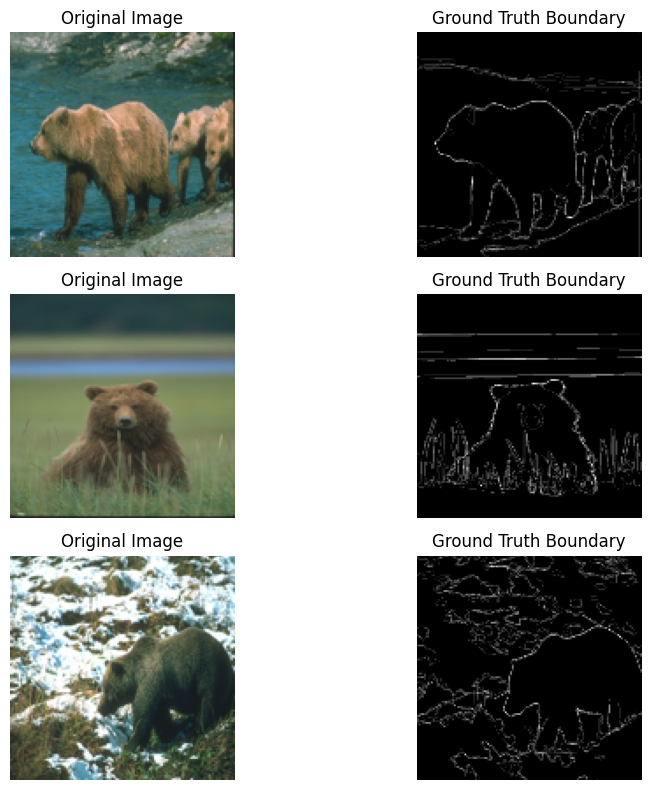

In [10]:
plt.figure(figsize=(10, 8))

for i in range(3):
    plt.subplot(3, 2, 2 * i + 1)
    plt.imshow(x_train[i])
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(3, 2, 2 * i + 2)
    plt.imshow(y_train[i].squeeze(), cmap="gray")
    plt.title("Ground Truth Boundary")
    plt.axis("off")

plt.tight_layout()
plt.show()

**U-Net Modeling**

>A compact U-Net architecture is used for pixel-level boundary detection. The encoder extracts visual features, while the decoder reconstructs spatial information. Skip connections help preserve important image details.

In [11]:
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D,
    UpSampling2D, Concatenate
)

def conv_block(x, filters):
    x = Conv2D(filters, 3, activation="relu", padding="same")(x)
    x = Conv2D(filters, 3, activation="relu", padding="same")(x)
    return x

inputs = Input((128, 128, 3))

# Encoder
c1 = conv_block(inputs, 16)
p1 = MaxPooling2D()(c1)

c2 = conv_block(p1, 32)
p2 = MaxPooling2D()(c2)

# Bottleneck
b = conv_block(p2, 64)

# Decoder
u2 = UpSampling2D()(b)
u2 = Concatenate()([u2, c2])
c3 = conv_block(u2, 32)

u1 = UpSampling2D()(c3)
u1 = Concatenate()([u1, c1])
c4 = conv_block(u1, 16)

outputs = Conv2D(1, 1, activation="sigmoid")(c4)

model = Model(inputs, outputs)

In [12]:
def dice_coef(y_true, y_pred):
    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true * y_pred)

    return (2.0 * intersection + 1e-6) / (
        tf.reduce_sum(y_true) +
        tf.reduce_sum(y_pred) +
        1e-6
    )

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[dice_coef]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 96)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │     27,680 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │      9,248 │ conv2d_6[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 48)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │      6,928 │ concatenate_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │      2,320 │ conv2d_8[0][0]  

 Total params: 118,273 (462.00 KB)

 Trainable params: 118,273 (462.00 KB)

 Non-trainable params: 0 (0.00 B)

**Model Training**

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2
)

In [14]:
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=25,
    batch_size=8,
    callbacks=[early_stopping, reduce_lr],
    verbose=2
)

Epoch 1/25
25/25 - 20s - 784ms/step - dice_coef: 0.0192 - loss: 0.2675 - val_dice_coef: 0.0090 - val_loss: 0.1246 - learning_rate: 0.0010
Epoch 2/25
25/25 - 14s - 546ms/step - dice_coef: 0.0141 - loss: 0.1131 - val_dice_coef: 0.0120 - val_loss: 0.1009 - learning_rate: 0.0010
Epoch 3/25
25/25 - 20s - 815ms/step - dice_coef: 0.0171 - loss: 0.0951 - val_dice_coef: 0.0163 - val_loss: 0.0889 - learning_rate: 0.0010
Epoch 4/25
25/25 - 13s - 526ms/step - dice_coef: 0.0211 - loss: 0.0889 - val_dice_coef: 0.0184 - val_loss: 0.0871 - learning_rate: 0.0010
Epoch 5/25
25/25 - 15s - 595ms/step - dice_coef: 0.0229 - loss: 0.0874 - val_dice_coef: 0.0235 - val_loss: 0.0848 - learning_rate: 0.0010
Epoch 6/25
25/25 - 13s - 536ms/step - dice_coef: 0.0245 - loss: 0.0862 - val_dice_coef: 0.0234 - val_loss: 0.0845 - learning_rate: 0.0010
Epoch 7/25
25/25 - 13s - 536ms/step - dice_coef: 0.0251 - loss: 0.0858 - val_dice_coef: 0.0239 - val_loss: 0.0842 - learning_rate: 0.0010
Epoch 8/25
25/25 - 15s - 580ms/ste

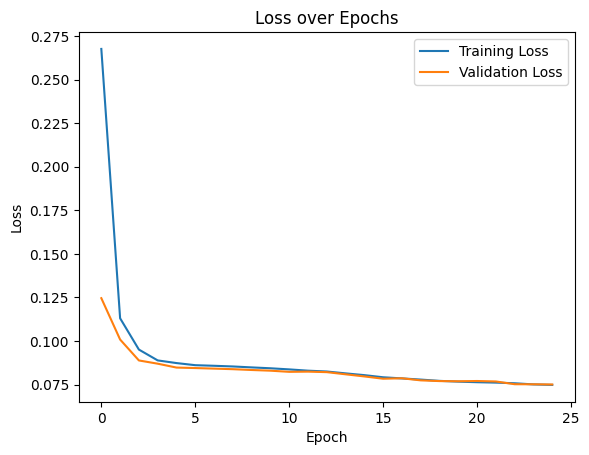

In [15]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

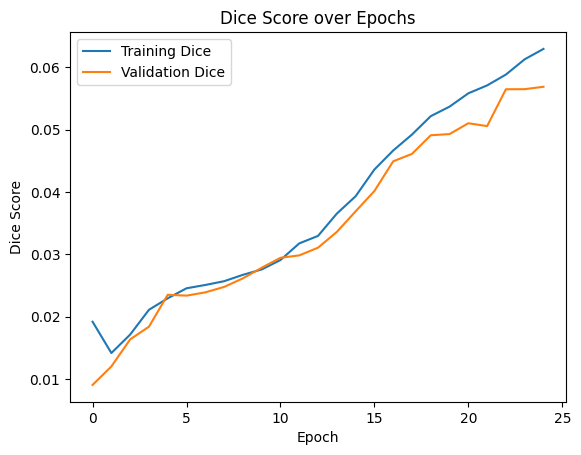

In [16]:
plt.plot(history.history["dice_coef"], label="Training Dice")
plt.plot(history.history["val_dice_coef"], label="Validation Dice")

plt.title("Dice Score over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.legend()
plt.show()

In [17]:
test_loss, test_dice = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Dice Score: {test_dice:.4f}")

Test Loss: 0.0793
Test Dice Score: 0.0586


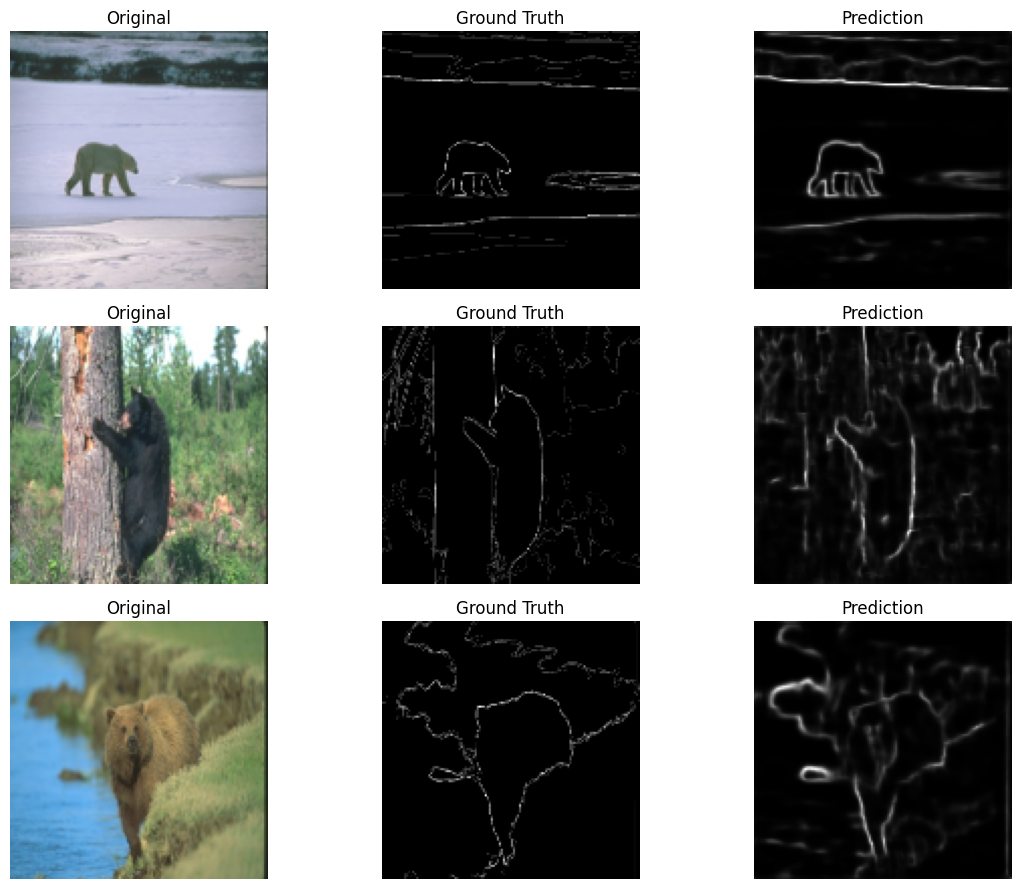

In [18]:
predictions = model.predict(x_test[:3], verbose=0)

plt.figure(figsize=(12, 9))

for i in range(3):
    plt.subplot(3, 3, 3 * i + 1)
    plt.imshow(x_test[i])
    plt.title("Original")
    plt.axis("off")

    plt.subplot(3, 3, 3 * i + 2)
    plt.imshow(y_test[i].squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(3, 3, 3 * i + 3)
    plt.imshow(predictions[i].squeeze(), cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
model.save("bsds500_unet_boundary_model.keras")

In [20]:
loaded_model = tf.keras.models.load_model(
    "bsds500_unet_boundary_model.keras",
    compile=False
)

### Summary

This project presents an approach to image boundary detection using the **BSDS500 dataset** and a compact **U-Net convolutional neural network**.

The workflow includes dataset preparation, ground-truth boundary processing, model training, validation, evaluation, prediction, and model saving.

A U-Net architecture was used to learn pixel-level visual information and generate boundary maps for unseen images. Early Stopping and learning-rate reduction were applied to improve training efficiency and reduce unnecessary epochs.

The final model was evaluated on the independent test set using **Binary Crossentropy loss** and the **Dice coefficient**.

The results indicate that the model learned visible boundary patterns, while the Dice score suggests that further improvement is possible.

Overall, the project presents a complete deep learning workflow for image segmentation and boundary detection using structured training, validation, and test data.